In [9]:
import os
# PySpark spark
os.environ['PYSPARK_PYTHON'] = 'python'

## Data Ingestion


In [3]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Bus Travel Time Prediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

print("Spark Version:", spark.version)
print("Spark Session Created Successfully!")

# Load the dataset
file_path = "c:/4th Semester/Siddhartha Sir/Assignment Dataset/bodds_archive_20260123_nO8P0D3/Metroline Travel Limited_24/bus_data_comprehensive.csv"

df = spark.read.csv(file_path, header=True, inferSchema=True)

print("\n=== Dataset Loaded Successfully ===")
print(f"Total Rows: {df.count():,}")
print(f"Total Columns: {len(df.columns)}")

# Show basic structure
print("\n=== Dataset Schema ===")
df.printSchema()

# Show first few rows
print("\n=== First 5 Rows ===")
df.show(5, truncate=False)

# Basic statistics
print("\n=== Basic Statistics ===")
df.select('runtime_seconds', 'distance_meters', 'from_sequence_number', 'to_sequence_number').describe().show()

Spark Version: 4.0.1
Spark Session Created Successfully!

=== Dataset Loaded Successfully ===
Total Rows: 40,342
Total Columns: 38

=== Dataset Schema ===
root
 |-- source_file: string (nullable = true)
 |-- creation_date: timestamp (nullable = true)
 |-- modification_date: timestamp (nullable = true)
 |-- operator_code: string (nullable = true)
 |-- operator_name: string (nullable = true)
 |-- service_code: string (nullable = true)
 |-- line_name: integer (nullable = true)
 |-- operating_start_date: date (nullable = true)
 |-- operating_end_date: date (nullable = true)
 |-- journey_pattern_section_id: string (nullable = true)
 |-- timing_link_id: string (nullable = true)
 |-- route_link_ref: string (nullable = true)
 |-- from_stop_id: string (nullable = true)
 |-- from_stop_name: string (nullable = true)
 |-- from_stop_indicator: string (nullable = true)
 |-- from_locality_name: string (nullable = true)
 |-- from_locality_qualifier: string (nullable = true)
 |-- from_latitude: string 

## Data Cleaning

In [4]:
print("="*70)
print("DATA CLEANING")
print("="*70)

# Check initial count
initial_count = df.count()
print(f"\n1. Initial Dataset Size: {initial_count:,} rows")

# Check missing values in critical columns
print("\n2. Missing Values Check:")
missing_check = df.select([
    count(when(col('runtime_seconds').isNull(), 1)).alias('runtime_missing'),
    count(when(col('distance_meters').isNull(), 1)).alias('distance_missing'),
    count(when(col('from_stop_id').isNull(), 1)).alias('from_stop_missing'),
    count(when(col('to_stop_id').isNull(), 1)).alias('to_stop_missing'),
    count(when(col('line_name').isNull(), 1)).alias('line_missing')
]).collect()[0]

print(f"   - runtime_seconds missing: {missing_check['runtime_missing']}")
print(f"   - distance_meters missing: {missing_check['distance_missing']}")
print(f"   - from_stop_id missing: {missing_check['from_stop_missing']}")
print(f"   - to_stop_id missing: {missing_check['to_stop_missing']}")
print(f"   - line_name missing: {missing_check['line_missing']}")

# Step 1: Remove rows with missing target variable (runtime_seconds)
df_clean = df.filter(col('runtime_seconds').isNotNull())
after_target_filter = df_clean.count()
print(f"\n3. After removing missing runtime_seconds: {after_target_filter:,} rows")
print(f"   Removed: {initial_count - after_target_filter:,} rows")

# Step 2: Remove rows with missing distance_meters
df_clean = df_clean.filter(col('distance_meters').isNotNull())
after_distance_filter = df_clean.count()
print(f"\n4. After removing missing distance_meters: {after_distance_filter:,} rows")
print(f"   Removed: {after_target_filter - after_distance_filter:,} rows")

# Step 3: Remove rows with zero or negative distance
df_clean = df_clean.filter(col('distance_meters') > 0)
after_zero_distance = df_clean.count()
print(f"\n5. After removing zero/negative distance: {after_zero_distance:,} rows")
print(f"   Removed: {after_distance_filter - after_zero_distance:,} rows")

# Step 4: Remove rows with zero or negative runtime
df_clean = df_clean.filter(col('runtime_seconds') > 0)
after_zero_runtime = df_clean.count()
print(f"\n6. After removing zero/negative runtime: {after_zero_runtime:,} rows")
print(f"   Removed: {after_zero_distance - after_zero_runtime:,} rows")

# Step 5: Create speed column and remove outliers
df_clean = df_clean.withColumn('speed_kmh', 
                               (col('distance_meters') / col('runtime_seconds')) * 3.6)

# Calculate speed percentiles for outlier detection
speed_stats = df_clean.select(
    percentile_approx('speed_kmh', 0.01).alias('p1'),
    percentile_approx('speed_kmh', 0.99).alias('p99')
).collect()[0]

print(f"\n7. Speed Statistics:")
print(f"   1st percentile: {speed_stats['p1']:.2f} km/h")
print(f"   99th percentile: {speed_stats['p99']:.2f} km/h")

# Remove extreme speed outliers (unrealistic speeds)
df_clean = df_clean.filter(
    (col('speed_kmh') >= 2) & (col('speed_kmh') <= 80)
)
after_speed_filter = df_clean.count()
print(f"\n8. After removing speed outliers (2-80 km/h): {after_speed_filter:,} rows")
print(f"   Removed: {after_zero_runtime - after_speed_filter:,} rows")

# Step 6: Remove duplicate rows
df_clean = df_clean.dropDuplicates()
after_duplicates = df_clean.count()
print(f"\n9. After removing duplicates: {after_duplicates:,} rows")
print(f"   Removed: {after_speed_filter - after_duplicates:,} rows")

# Final summary
print("\n" + "="*70)
print("DATA CLEANING SUMMARY")
print("="*70)
print(f"Initial rows:     {initial_count:,}")
print(f"Final rows:       {after_duplicates:,}")
print(f"Total removed:    {initial_count - after_duplicates:,}")
print(f"Retention rate:   {(after_duplicates/initial_count)*100:.2f}%")
print("="*70)

# Cache the cleaned dataframe for better performance
df_clean.cache()
print(f"\n✓ Cleaned dataset cached in memory")

DATA CLEANING

1. Initial Dataset Size: 40,342 rows

2. Missing Values Check:
   - runtime_seconds missing: 1021
   - distance_meters missing: 0
   - from_stop_id missing: 0
   - to_stop_id missing: 0
   - line_name missing: 0

3. After removing missing runtime_seconds: 39,321 rows
   Removed: 1,021 rows

4. After removing missing distance_meters: 39,321 rows
   Removed: 0 rows

5. After removing zero/negative distance: 39,321 rows
   Removed: 0 rows

6. After removing zero/negative runtime: 39,321 rows
   Removed: 0 rows

7. Speed Statistics:
   1st percentile: 4.73 km/h
   99th percentile: 56.46 km/h

8. After removing speed outliers (2-80 km/h): 39,113 rows
   Removed: 208 rows

9. After removing duplicates: 39,113 rows
   Removed: 0 rows

DATA CLEANING SUMMARY
Initial rows:     40,342
Final rows:       39,113
Total removed:    1,229
Retention rate:   96.95%

✓ Cleaned dataset cached in memory


## Data Pre processing (Feature Engineering)

In [5]:
print("="*70)
print("DATA PREPROCESSING & FEATURE ENGINEERING")
print("="*70)

# Import Window for windowing functions
from pyspark.sql.window import Window

# Step 1: Create derived features
print("\n1. Creating Derived Features...")

# Create stop_pair feature
df_processed = df_clean.withColumn(
    'stop_pair',
    concat_ws('_to_', col('from_stop_id'), col('to_stop_id'))
)

# Create distance categories
df_processed = df_processed.withColumn(
    'distance_category',
    when(col('distance_meters') <= 200, 'short')
    .when(col('distance_meters') <= 500, 'medium')
    .when(col('distance_meters') <= 1000, 'long')
    .otherwise('very_long')
)

# Calculate route position (if needed)
# Get max sequence per journey pattern
window_spec = Window.partitionBy('journey_pattern_section_id')
df_processed = df_processed.withColumn(
    'max_sequence',
    max('to_sequence_number').over(window_spec)
)
df_processed = df_processed.withColumn(
    'route_position',
    col('from_sequence_number') / col('max_sequence')
)

print("   ✓ stop_pair created")
print("   ✓ distance_category created")
print("   ✓ route_position created")

# Step 2: Select relevant features
print("\n2. Selecting Relevant Features...")

features_to_keep = [
    'runtime_seconds',          # Target
    'distance_meters',          # Numerical
    'from_sequence_number',     # Numerical
    'to_sequence_number',       # Numerical
    'speed_kmh',                # Numerical (derived)
    'route_position',           # Numerical (derived)
    'from_stop_id',             # Categorical
    'to_stop_id',               # Categorical
    'stop_pair',                # Categorical (derived)
    'line_name',                # Categorical
    'from_locality_name',       # Categorical
    'to_locality_name',         # Categorical
    'from_timing_status',       # Categorical
    'to_timing_status',         # Categorical
    'distance_category'         # Categorical (derived)
]

df_features = df_processed.select(features_to_keep)

print(f"   ✓ Selected {len(features_to_keep)} features")

# Step 3: Handle missing values in categorical columns
print("\n3. Handling Missing Values...")

# Fill missing categorical values with 'UNKNOWN'
categorical_cols = ['from_locality_name', 'to_locality_name', 
                   'from_timing_status', 'to_timing_status']

for col_name in categorical_cols:
    null_count = df_features.filter(col(col_name).isNull()).count()
    if null_count > 0:
        print(f"   - Filling {null_count} missing values in {col_name}")
        df_features = df_features.fillna('UNKNOWN', subset=[col_name])
    else:
        print(f"   ✓ {col_name} has no missing values")

# Step 4: Create StringIndexers for categorical features
print("\n4. Encoding Categorical Features...")

categorical_features = [
    'from_stop_id', 'to_stop_id', 'stop_pair', 'line_name',
    'from_locality_name', 'to_locality_name',
    'from_timing_status', 'to_timing_status', 'distance_category'
]

indexers = []
indexed_cols = []

for cat_col in categorical_features:
    indexer = StringIndexer(
        inputCol=cat_col,
        outputCol=f"{cat_col}_indexed",
        handleInvalid='keep'  # Keep unknown categories
    )
    indexers.append(indexer)
    indexed_cols.append(f"{cat_col}_indexed")
    
print(f"   ✓ Created {len(indexers)} StringIndexers")

# Step 5: Prepare numerical features for scaling
print("\n5. Preparing Numerical Features for Scaling...")

numerical_features = [
    'distance_meters',
    'from_sequence_number',
    'to_sequence_number',
    'speed_kmh',
    'route_position'
]

print(f"   ✓ Identified {len(numerical_features)} numerical features")

# Step 6: Create feature vector (before scaling)
print("\n6. Creating Feature Vector...")

# Combine indexed categorical and numerical features
all_feature_cols = indexed_cols + numerical_features

vector_assembler = VectorAssembler(
    inputCols=all_feature_cols,
    outputCol='unscaled_features',
    handleInvalid='skip'
)

print(f"   ✓ VectorAssembler created with {len(all_feature_cols)} features")

# Step 7: Create StandardScaler
print("\n7. Creating StandardScaler...")

scaler = StandardScaler(
    inputCol='unscaled_features',
    outputCol='features',
    withMean=True,
    withStd=True
)

print("   ✓ StandardScaler created")

# Step 8: Build preprocessing pipeline
print("\n8. Building Preprocessing Pipeline...")

preprocessing_stages = indexers + [vector_assembler, scaler]
preprocessing_pipeline = Pipeline(stages=preprocessing_stages)

print(f"   ✓ Pipeline created with {len(preprocessing_stages)} stages")

print("\n" + "="*70)
print("PREPROCESSING SUMMARY")
print("="*70)
print(f"Total Features:        {len(all_feature_cols)}")
print(f"Categorical Features:  {len(indexed_cols)}")
print(f"Numerical Features:    {len(numerical_features)}")
print(f"Pipeline Stages:       {len(preprocessing_stages)}")
print("="*70)

# Show sample of preprocessed data (before fitting pipeline)
print("\n✓ Preprocessed dataset ready for train-test split")
df_features.show(5)

DATA PREPROCESSING & FEATURE ENGINEERING

1. Creating Derived Features...
   ✓ stop_pair created
   ✓ distance_category created
   ✓ route_position created

2. Selecting Relevant Features...
   ✓ Selected 15 features

3. Handling Missing Values...
   ✓ from_locality_name has no missing values
   ✓ to_locality_name has no missing values
   ✓ from_timing_status has no missing values
   ✓ to_timing_status has no missing values

4. Encoding Categorical Features...
   ✓ Created 9 StringIndexers

5. Preparing Numerical Features for Scaling...
   ✓ Identified 5 numerical features

6. Creating Feature Vector...
   ✓ VectorAssembler created with 14 features

7. Creating StandardScaler...
   ✓ StandardScaler created

8. Building Preprocessing Pipeline...
   ✓ Pipeline created with 11 stages

PREPROCESSING SUMMARY
Total Features:        14
Categorical Features:  9
Numerical Features:    5
Pipeline Stages:       11

✓ Preprocessed dataset ready for train-test split
+---------------+---------------

## Data Visualization

DATA VISUALIZATION

Converting sample data to Pandas for visualization...
Using 3,862 records for visualization

1. Creating Distribution of Runtime (Target Variable)...


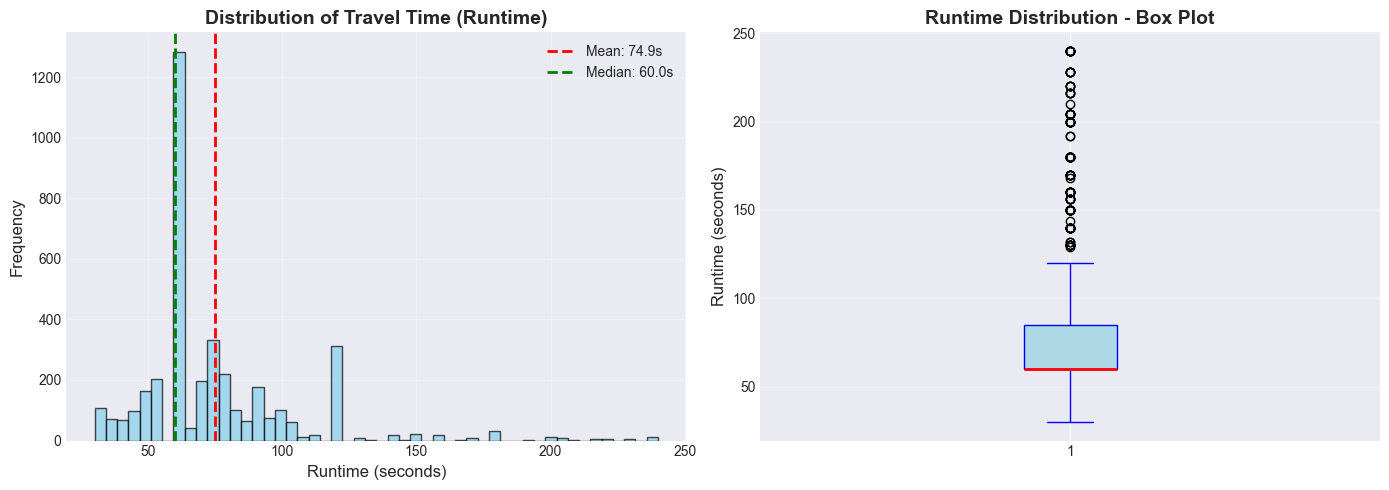

   ✓ Runtime Stats: Mean=74.87s, Median=60.00s, Std=30.92s

2. Creating Distance vs Runtime Scatter Plot...


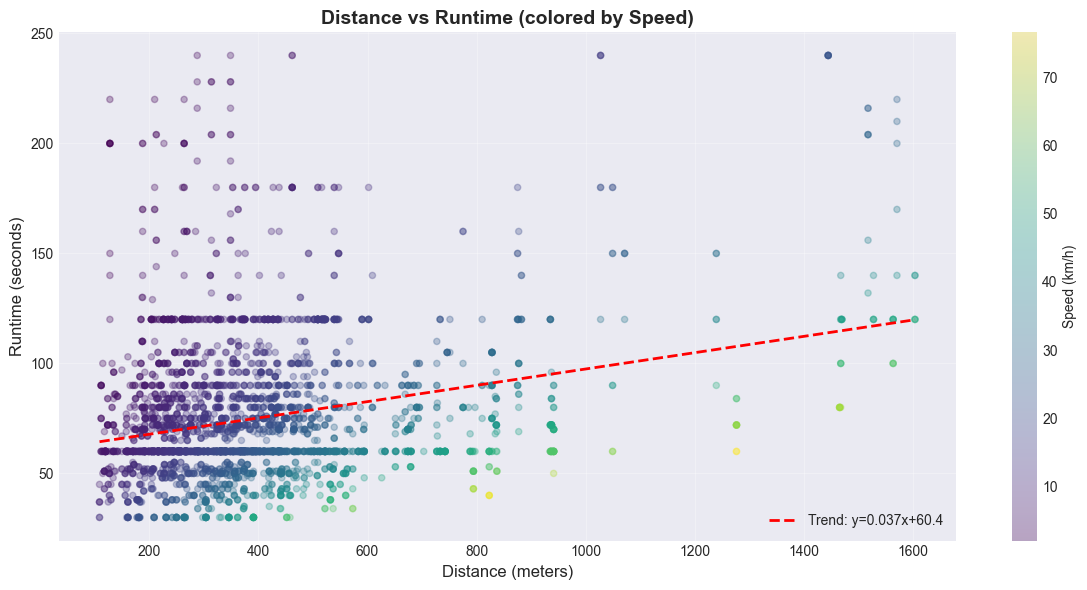

   ✓ Correlation (Distance vs Runtime): 0.2666

3. Creating Runtime Distribution by Bus Line...


C:\Users\acer\AppData\Local\Temp\ipykernel_23008\3579187047.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='line_name', y='runtime_seconds', order=line_order, palette='Set2')


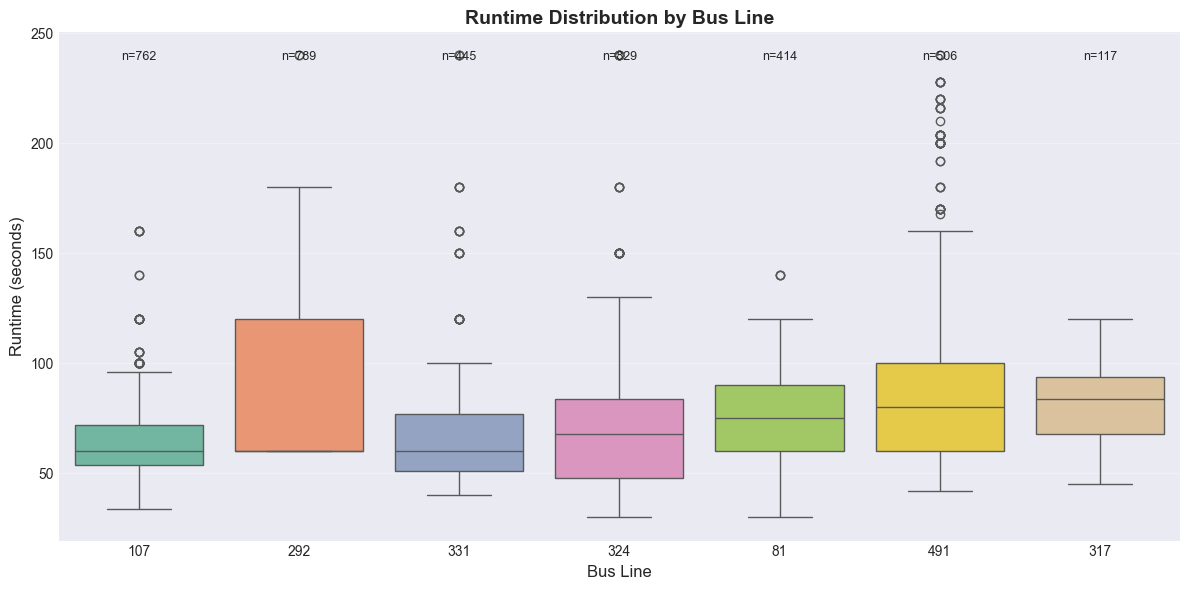

   ✓ Different lines show varying runtime patterns

4. Creating Speed Distribution by Distance Category...


C:\Users\acer\AppData\Local\Temp\ipykernel_23008\3579187047.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_viz_cat, x='distance_category', y='speed_kmh',


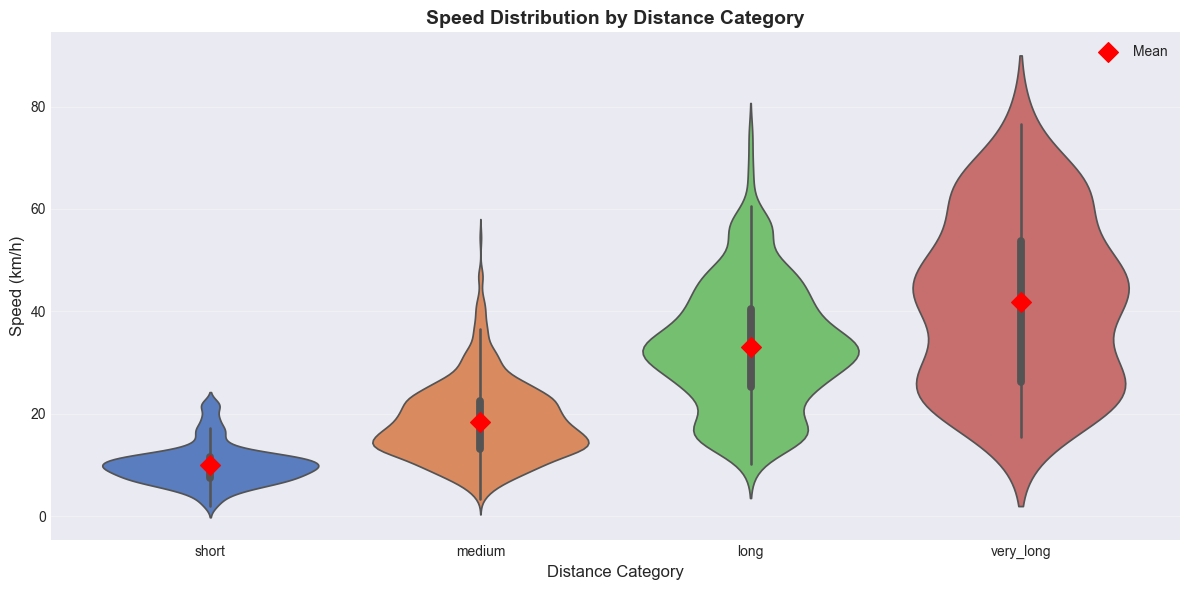

   ✓ Speed varies significantly by distance category

5. Creating Correlation Heatmap...


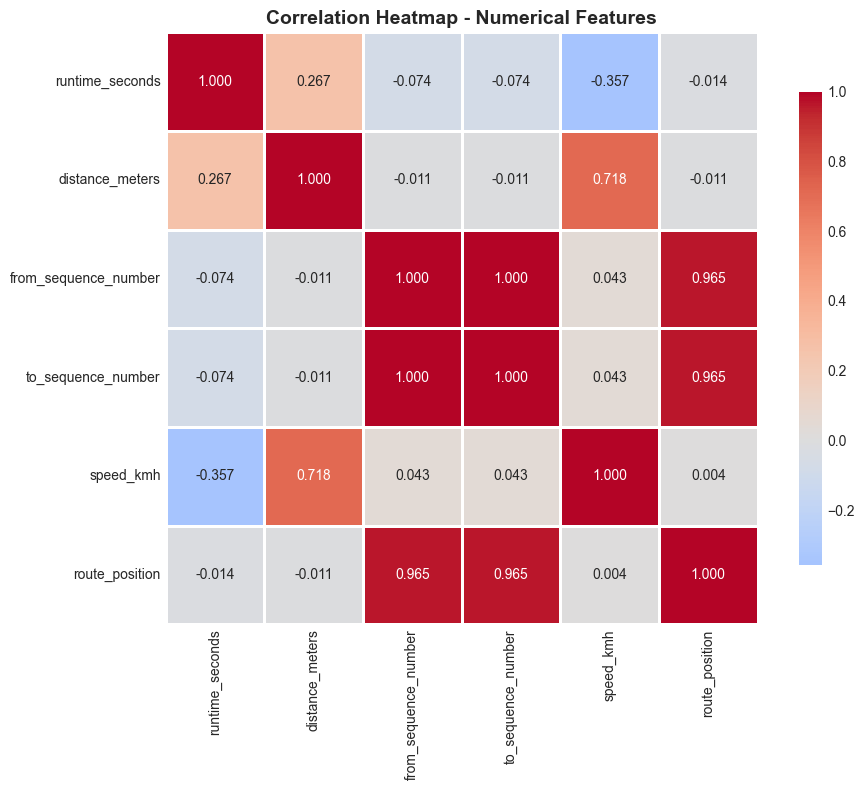

   ✓ Key correlations identified:
      - Distance vs Runtime: 0.267
      - Speed vs Runtime: -0.357
      - Sequence vs Runtime: -0.074

✓ ALL VISUALIZATIONS COMPLETED


In [6]:
print("="*70)
print("DATA VISUALIZATION")
print("="*70)

# Convert to Pandas for visualization
print("\nConverting sample data to Pandas for visualization...")
df_viz = df_features.sample(False, 0.1, seed=42).toPandas()  # Sample 10% for faster viz
print(f"Using {len(df_viz):,} records for visualization\n")

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# VISUALIZATION 1: Distribution of Target Variable (runtime_seconds)
# ============================================================
print("1. Creating Distribution of Runtime (Target Variable)...")

plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df_viz['runtime_seconds'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Runtime (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Travel Time (Runtime)', fontsize=14, fontweight='bold')
plt.axvline(df_viz['runtime_seconds'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_viz["runtime_seconds"].mean():.1f}s')
plt.axvline(df_viz['runtime_seconds'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_viz["runtime_seconds"].median():.1f}s')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(df_viz['runtime_seconds'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'))
plt.ylabel('Runtime (seconds)', fontsize=12)
plt.title('Runtime Distribution - Box Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"   ✓ Runtime Stats: Mean={df_viz['runtime_seconds'].mean():.2f}s, Median={df_viz['runtime_seconds'].median():.2f}s, Std={df_viz['runtime_seconds'].std():.2f}s\n")


# ============================================================
# VISUALIZATION 2: Distance vs Runtime (Scatter Plot with Regression)
# ============================================================
print("2. Creating Distance vs Runtime Scatter Plot...")

plt.figure(figsize=(12, 6))
plt.scatter(df_viz['distance_meters'], df_viz['runtime_seconds'], 
           alpha=0.3, c=df_viz['speed_kmh'], cmap='viridis', s=20)
plt.colorbar(label='Speed (km/h)')
plt.xlabel('Distance (meters)', fontsize=12)
plt.ylabel('Runtime (seconds)', fontsize=12)
plt.title('Distance vs Runtime (colored by Speed)', fontsize=14, fontweight='bold')

# Add trend line
z = np.polyfit(df_viz['distance_meters'], df_viz['runtime_seconds'], 1)
p = np.poly1d(z)
plt.plot(df_viz['distance_meters'].sort_values(), 
         p(df_viz['distance_meters'].sort_values()), 
         "r--", linewidth=2, label=f'Trend: y={z[0]:.3f}x+{z[1]:.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = df_viz['distance_meters'].corr(df_viz['runtime_seconds'])
print(f"   ✓ Correlation (Distance vs Runtime): {corr:.4f}\n")


# ============================================================
# VISUALIZATION 3: Runtime by Bus Line (Box Plot)
# ============================================================
print("3. Creating Runtime Distribution by Bus Line...")

plt.figure(figsize=(12, 6))
df_viz_sorted = df_viz.sort_values('line_name')
line_order = df_viz.groupby('line_name')['runtime_seconds'].median().sort_values().index

sns.boxplot(data=df_viz, x='line_name', y='runtime_seconds', order=line_order, palette='Set2')
plt.xlabel('Bus Line', fontsize=12)
plt.ylabel('Runtime (seconds)', fontsize=12)
plt.title('Runtime Distribution by Bus Line', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

# Add count labels
for i, line in enumerate(line_order):
    count = len(df_viz[df_viz['line_name'] == line])
    plt.text(i, plt.ylim()[1]*0.95, f'n={count}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("   ✓ Different lines show varying runtime patterns\n")


# ============================================================
# VISUALIZATION 4: Speed Distribution by Distance Category
# ============================================================
print("4. Creating Speed Distribution by Distance Category...")

plt.figure(figsize=(12, 6))

# Define category order
cat_order = ['short', 'medium', 'long', 'very_long']
df_viz_cat = df_viz[df_viz['distance_category'].isin(cat_order)]

sns.violinplot(data=df_viz_cat, x='distance_category', y='speed_kmh', 
              order=cat_order, palette='muted', inner='box')
plt.xlabel('Distance Category', fontsize=12)
plt.ylabel('Speed (km/h)', fontsize=12)
plt.title('Speed Distribution by Distance Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

# Add mean markers
for i, cat in enumerate(cat_order):
    if cat in df_viz_cat['distance_category'].values:
        mean_speed = df_viz_cat[df_viz_cat['distance_category'] == cat]['speed_kmh'].mean()
        plt.scatter(i, mean_speed, color='red', s=100, zorder=5, marker='D', label='Mean' if i == 0 else '')

plt.legend()
plt.tight_layout()
plt.show()

print("   ✓ Speed varies significantly by distance category\n")


# ============================================================
# VISUALIZATION 5: Correlation Heatmap of Numerical Features
# ============================================================
print("5. Creating Correlation Heatmap...")

numerical_cols = ['runtime_seconds', 'distance_meters', 'from_sequence_number', 
                 'to_sequence_number', 'speed_kmh', 'route_position']

correlation_matrix = df_viz[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("   ✓ Key correlations identified:")
print(f"      - Distance vs Runtime: {correlation_matrix.loc['distance_meters', 'runtime_seconds']:.3f}")
print(f"      - Speed vs Runtime: {correlation_matrix.loc['speed_kmh', 'runtime_seconds']:.3f}")
print(f"      - Sequence vs Runtime: {correlation_matrix.loc['from_sequence_number', 'runtime_seconds']:.3f}")

print("\n" + "="*70)
print("✓ ALL VISUALIZATIONS COMPLETED")
print("="*70)

## Train test Split

In [7]:
print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

# Import Python's built-in abs function to avoid conflict with PySpark's abs
from builtins import abs as python_abs

# Step 1: Fit the preprocessing pipeline on the entire dataset
print("\n1. Fitting Preprocessing Pipeline...")
preprocessing_model = preprocessing_pipeline.fit(df_features)
print("   ✓ Pipeline fitted successfully")

# Step 2: Transform the data
print("\n2. Transforming Dataset...")
df_transformed = preprocessing_model.transform(df_features)
print("   ✓ Dataset transformed")

# Step 3: Select only necessary columns for modeling
print("\n3. Selecting Final Columns...")
df_model = df_transformed.select('features', 'runtime_seconds')
df_model = df_model.withColumnRenamed('runtime_seconds', 'label')
print("   ✓ Final dataset prepared with 'features' and 'label'")

# Step 4: Split into train and test sets
print("\n4. Splitting Data (80% Train, 20% Test)...")
train_data, test_data = df_model.randomSplit([0.8, 0.2], seed=42)

# Cache the splits for better performance
train_data.cache()
test_data.cache()

train_count = train_data.count()
test_count = test_data.count()
total_count = train_count + test_count

print(f"\n5. Split Summary:")
print(f"   Training Set:   {train_count:,} rows ({(train_count/total_count)*100:.1f}%)")
print(f"   Test Set:       {test_count:,} rows ({(test_count/total_count)*100:.1f}%)")
print(f"   Total:          {total_count:,} rows")

# Step 6: Verify data distribution
print("\n6. Verifying Target Distribution...")
train_stats = train_data.select(
    mean('label').alias('train_mean'),
    stddev('label').alias('train_std')
).collect()[0]

test_stats = test_data.select(
    mean('label').alias('test_mean'),
    stddev('label').alias('test_std')
).collect()[0]

print(f"   Training Set - Mean: {train_stats['train_mean']:.2f}s, Std: {train_stats['train_std']:.2f}s")
print(f"   Test Set     - Mean: {test_stats['test_mean']:.2f}s, Std: {test_stats['test_std']:.2f}s")
print(f"   Difference   - Mean: {python_abs(train_stats['train_mean'] - test_stats['test_mean']):.2f}s")

if python_abs(train_stats['train_mean'] - test_stats['test_mean']) < 5:
    print("   ✓ Train and test distributions are similar")
else:
    print("   ⚠ Train and test distributions differ slightly")

print("\n" + "="*70)
print("✓ DATA SPLIT COMPLETED")
print("="*70)

# Show sample from each set
print("\n7. Sample from Training Set:")
train_data.show(3, truncate=False)

print("\n8. Sample from Test Set:")
test_data.show(3, truncate=False)

TRAIN-TEST SPLIT

1. Fitting Preprocessing Pipeline...
   ✓ Pipeline fitted successfully

2. Transforming Dataset...
   ✓ Dataset transformed

3. Selecting Final Columns...
   ✓ Final dataset prepared with 'features' and 'label'

4. Splitting Data (80% Train, 20% Test)...

5. Split Summary:
   Training Set:   31,262 rows (79.9%)
   Test Set:       7,851 rows (20.1%)
   Total:          39,113 rows

6. Verifying Target Distribution...
   Training Set - Mean: 75.17s, Std: 31.66s
   Test Set     - Mean: 74.68s, Std: 30.67s
   Difference   - Mean: 0.49s
   ✓ Train and test distributions are similar

✓ DATA SPLIT COMPLETED

7. Sample from Training Set:
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                        

## Model Training

In [8]:
print("="*70)
print("MODEL TRAINING - LINEAR REGRESSION")
print("="*70)

# Import time for tracking training duration
import time

# Dictionary to store trained model
models = {}
training_times = {}

# ============================================================
# LINEAR REGRESSION MODEL
# ============================================================
print("\n1. Training Linear Regression Model...")

start_time = time.time()

lr = LinearRegression(
    featuresCol='features',
    labelCol='label',
    predictionCol='prediction',
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0,
    standardization=False  # Already standardized in preprocessing
)

lr_model = lr.fit(train_data)
lr_time = time.time() - start_time

models['Linear Regression'] = lr_model
training_times['Linear Regression'] = lr_time

print(f"   ✓ Linear Regression trained in {lr_time:.2f} seconds")
print(f"\n2. Model Details:")
print(f"   - Number of features: {len(lr_model.coefficients)}")
print(f"   - Intercept: {lr_model.intercept:.3f}")
print(f"   - Max iterations: {lr_model.getMaxIter()}")
print(f"   - Regularization parameter: {lr_model.getRegParam()}")

# Show top 10 coefficients (absolute values)
print(f"\n3. Top 10 Feature Coefficients (by absolute value):")
coefficients = lr_model.coefficients.toArray()
coef_indices = np.argsort(np.abs(coefficients))[-10:][::-1]

print(f"   {'Feature Index':<15} {'Coefficient':<15}")
print("   " + "-"*30)
for idx in coef_indices:
    print(f"   {idx:<15} {coefficients[idx]:>12.6f}")

# Training summary
train_summary = lr_model.summary

print(f"\n4. Training Summary:")
print(f"   - Total iterations: {train_summary.totalIterations}")
print(f"   - Objective history (last 5): {train_summary.objectiveHistory[-5:]}")
print(f"   - Training RMSE: {train_summary.rootMeanSquaredError:.2f} seconds")
print(f"   - Training R²: {train_summary.r2:.4f}")
print(f"   - Training MAE: {train_summary.meanAbsoluteError:.2f} seconds")

# ============================================================
# TRAINING SUMMARY
# ============================================================
print("\n" + "="*70)
print("MODEL TRAINING SUMMARY")
print("="*70)
print(f"Model:           Linear Regression")
print(f"Training Time:   {lr_time:.2f} seconds")
print(f"Status:          ✓ Successfully trained")
print("="*70)

print(f"\n✓ Model training completed!")

MODEL TRAINING - LINEAR REGRESSION

1. Training Linear Regression Model...
   ✓ Linear Regression trained in 6.44 seconds

2. Model Details:
   - Number of features: 14
   - Intercept: 75.108
   - Max iterations: 100
   - Regularization parameter: 0.01

3. Top 10 Feature Coefficients (by absolute value):
   Feature Index   Coefficient    
   ------------------------------
   12                -34.994242
   9                  34.828911
   13                  6.865095
   11                 -3.437867
   10                 -3.437867
   8                  -3.435082
   7                   0.980228
   6                   0.963952
   2                  -0.897765
   5                   0.828731

4. Training Summary:
   - Total iterations: 0
   - Objective history (last 5): [0.0]
   - Training RMSE: 16.51 seconds
   - Training R²: 0.7283
   - Training MAE: 10.69 seconds

MODEL TRAINING SUMMARY
Model:           Linear Regression
Training Time:   6.44 seconds
Status:          ✓ Successfully traine

## Model Evaluation

MODEL EVALUATION

1. Evaluating Linear Regression on Training Set...
----------------------------------------------------------------------

Training Set Performance:
   MAE:     10.69 seconds (0.18 minutes)
   RMSE:    16.51 seconds (0.28 minutes)
   MSE:    272.43
   R²:     0.7283


2. Evaluating Linear Regression on Test Set...
----------------------------------------------------------------------

Test Set Performance:
   MAE:     10.60 seconds (0.18 minutes)
   RMSE:    16.14 seconds (0.27 minutes)
   MSE:    260.59
   R²:     0.7229

TRAIN VS TEST COMPARISON

Metric          Training        Test            Difference     
----------------------------------------------------------------------
MAE (seconds)        10.6876       10.5971       -0.0905
RMSE (seconds)       16.5053       16.1428       -0.3626
R² Score              0.7283        0.7229       -0.0053
MSE                 272.4265      260.5886      -11.8379

3. Model Diagnosis:
   ✓ Model generalization looks good
   ✓ T

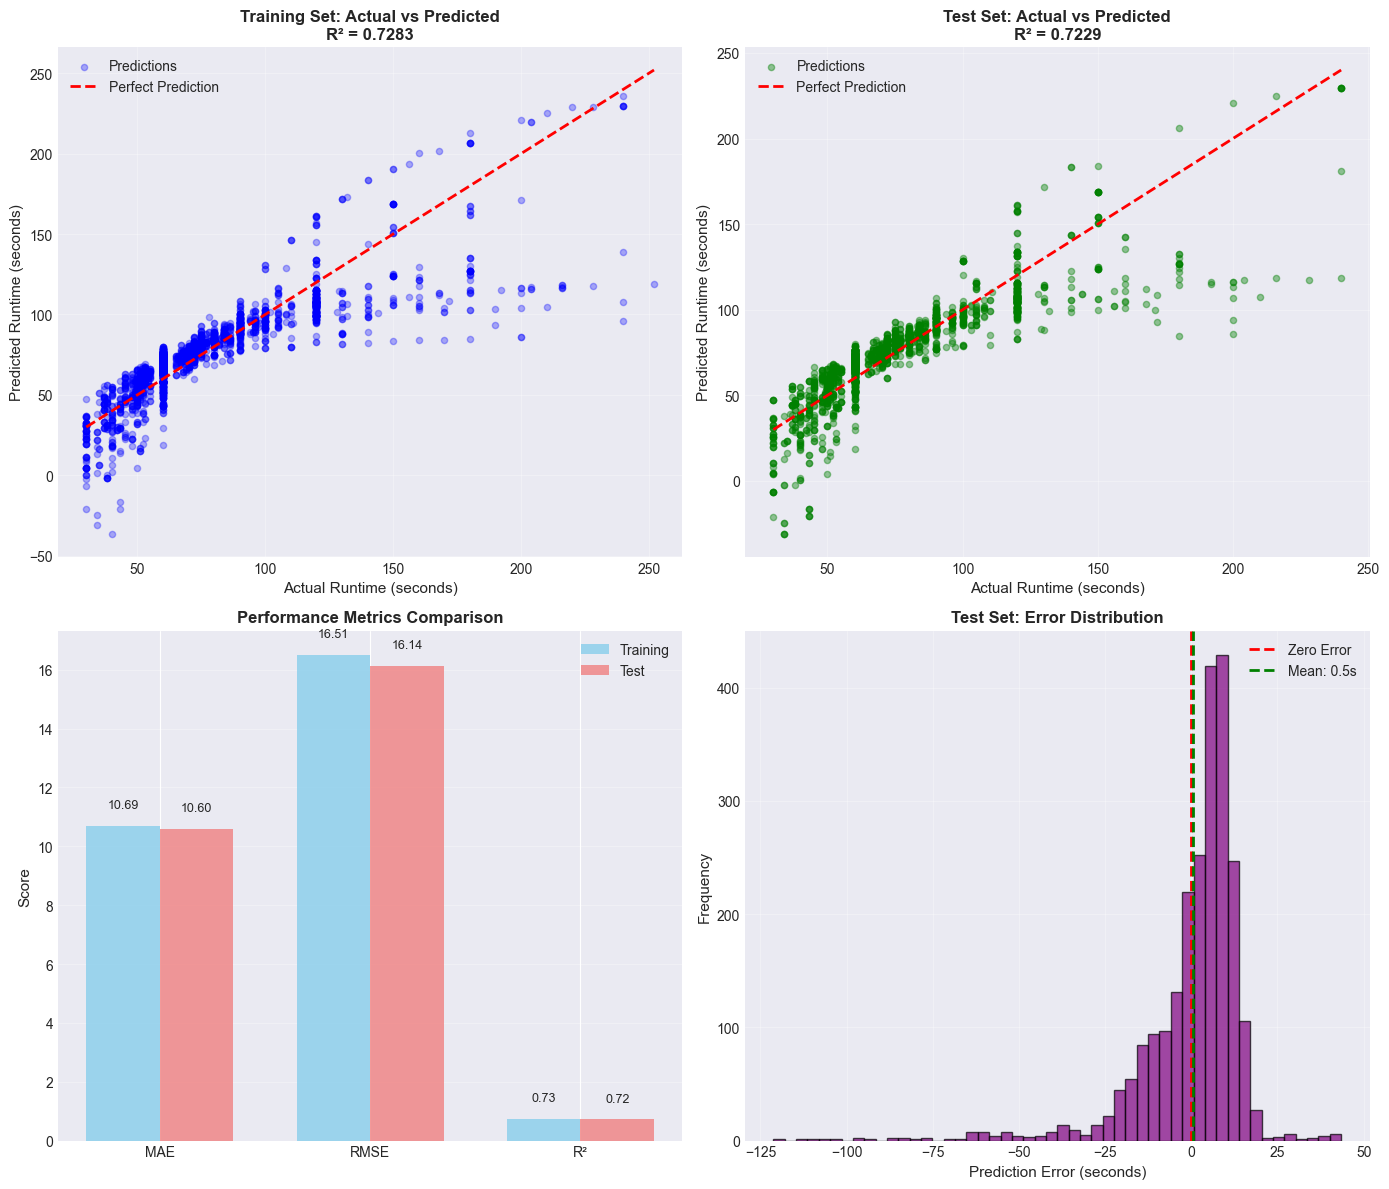

   ✓ Performance visualizations created

EVALUATION SUMMARY

Model: Linear Regression

Test Set Performance:
  • Mean Absolute Error:     10.60 seconds (±0.18 minutes)
  • Root Mean Squared Error: 16.14 seconds
  • R² Score:                0.7229

Interpretation:
  • Model explains 72.3% of variance in travel time
  • On average, predictions are off by ±10.6 seconds
  • ✓✓✓ EXCELLENT accuracy for operational use

✓ MODEL EVALUATION COMPLETED


In [10]:
print("="*70)
print("MODEL EVALUATION")
print("="*70)

# Create evaluators
mae_evaluator = RegressionEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='mae'
)

rmse_evaluator = RegressionEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='rmse'
)

r2_evaluator = RegressionEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='r2'
)

mse_evaluator = RegressionEvaluator(
    labelCol='label',
    predictionCol='prediction',
    metricName='mse'
)

# Dictionary to store evaluation results
evaluation_results = {}

print("\n1. Evaluating Linear Regression on Training Set...")
print("-"*70)

# Make predictions on training data
train_predictions = lr_model.transform(train_data)

# Calculate training metrics
train_mae = mae_evaluator.evaluate(train_predictions)
train_rmse = rmse_evaluator.evaluate(train_predictions)
train_r2 = r2_evaluator.evaluate(train_predictions)
train_mse = mse_evaluator.evaluate(train_predictions)

evaluation_results['train'] = {
    'mae': train_mae,
    'rmse': train_rmse,
    'r2': train_r2,
    'mse': train_mse
}

print(f"\nTraining Set Performance:")
print(f"   MAE:  {train_mae:>8.2f} seconds ({train_mae/60:.2f} minutes)")
print(f"   RMSE: {train_rmse:>8.2f} seconds ({train_rmse/60:.2f} minutes)")
print(f"   MSE:  {train_mse:>8.2f}")
print(f"   R²:   {train_r2:>8.4f}")


print("\n" + "="*70)
print("\n2. Evaluating Linear Regression on Test Set...")
print("-"*70)

# Make predictions on test data
test_predictions = lr_model.transform(test_data)

# Calculate test metrics
test_mae = mae_evaluator.evaluate(test_predictions)
test_rmse = rmse_evaluator.evaluate(test_predictions)
test_r2 = r2_evaluator.evaluate(test_predictions)
test_mse = mse_evaluator.evaluate(test_predictions)

evaluation_results['test'] = {
    'mae': test_mae,
    'rmse': test_rmse,
    'r2': test_r2,
    'mse': test_mse
}

print(f"\nTest Set Performance:")
print(f"   MAE:  {test_mae:>8.2f} seconds ({test_mae/60:.2f} minutes)")
print(f"   RMSE: {test_rmse:>8.2f} seconds ({test_rmse/60:.2f} minutes)")
print(f"   MSE:  {test_mse:>8.2f}")
print(f"   R²:   {test_r2:>8.4f}")


# ============================================================
# TRAIN VS TEST COMPARISON
# ============================================================
print("\n" + "="*70)
print("TRAIN VS TEST COMPARISON")
print("="*70)
print(f"\n{'Metric':<15} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*70)

metrics = ['mae', 'rmse', 'r2', 'mse']
metric_names = ['MAE (seconds)', 'RMSE (seconds)', 'R² Score', 'MSE']

for metric, name in zip(metrics, metric_names):
    train_val = evaluation_results['train'][metric]
    test_val = evaluation_results['test'][metric]
    diff = test_val - train_val
    
    print(f"{name:<15} {train_val:>12.4f}  {test_val:>12.4f}  {diff:>12.4f}")

# Check for overfitting/underfitting
print("\n3. Model Diagnosis:")
if test_r2 < 0.5:
    print("   ⚠ Underfitting - Model is too simple, consider:")
    print("      • Adding more features")
    print("      • Using polynomial features")
    print("      • Trying non-linear models")
elif test_r2 > train_r2 + 0.1:
    print("   ⚠ Potential issue - Test R² higher than train (unusual)")
elif train_r2 - test_r2 > 0.15:
    print("   ⚠ Overfitting detected - Model performs much better on training")
    print("      • Consider increasing regularization")
    print("      • Reduce feature complexity")
else:
    print("   ✓ Model generalization looks good")
    print(f"   ✓ Test R² ({test_r2:.4f}) is close to train R² ({train_r2:.4f})")


# ============================================================
# VISUALIZE MODEL PERFORMANCE
# ============================================================
print("\n4. Creating Performance Visualizations...")

# Convert small sample to pandas for visualization
train_pred_sample = train_predictions.select('label', 'prediction').sample(False, 0.1, seed=42).toPandas()
test_pred_sample = test_predictions.select('label', 'prediction').sample(False, 0.3, seed=42).toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Training Set - Actual vs Predicted
axes[0, 0].scatter(train_pred_sample['label'], train_pred_sample['prediction'], 
                  alpha=0.3, s=20, color='blue', label='Predictions')
axes[0, 0].plot([train_pred_sample['label'].min(), train_pred_sample['label'].max()], 
               [train_pred_sample['label'].min(), train_pred_sample['label'].max()], 
               'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Runtime (seconds)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Runtime (seconds)', fontsize=11)
axes[0, 0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Test Set - Actual vs Predicted
axes[0, 1].scatter(test_pred_sample['label'], test_pred_sample['prediction'], 
                  alpha=0.4, s=20, color='green', label='Predictions')
axes[0, 1].plot([test_pred_sample['label'].min(), test_pred_sample['label'].max()], 
               [test_pred_sample['label'].min(), test_pred_sample['label'].max()], 
               'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Runtime (seconds)', fontsize=11)
axes[0, 1].set_ylabel('Predicted Runtime (seconds)', fontsize=11)
axes[0, 1].set_title(f'Test Set: Actual vs Predicted\nR² = {test_r2:.4f}', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Metrics Comparison Bar Chart
metric_labels = ['MAE', 'RMSE', 'R²']
train_vals = [train_mae, train_rmse, train_r2]
test_vals = [test_mae, test_rmse, test_r2]

x = np.arange(len(metric_labels))
width = 0.35

axes[1, 0].bar(x - width/2, train_vals, width, label='Training', color='skyblue', alpha=0.8)
axes[1, 0].bar(x + width/2, test_vals, width, label='Test', color='lightcoral', alpha=0.8)
axes[1, 0].set_ylabel('Score', fontsize=11)
axes[1, 0].set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metric_labels)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (train_val, test_val) in enumerate(zip(train_vals, test_vals)):
    axes[1, 0].text(i - width/2, train_val + 0.5, f'{train_val:.2f}', ha='center', va='bottom', fontsize=9)
    axes[1, 0].text(i + width/2, test_val + 0.5, f'{test_val:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 4: Error Distribution
test_pred_sample['error'] = test_pred_sample['prediction'] - test_pred_sample['label']
axes[1, 1].hist(test_pred_sample['error'], bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1, 1].axvline(test_pred_sample['error'].mean(), color='green', linestyle='--', 
                  linewidth=2, label=f'Mean: {test_pred_sample["error"].mean():.1f}s')
axes[1, 1].set_xlabel('Prediction Error (seconds)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Test Set: Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("   ✓ Performance visualizations created")


# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*70)
print("EVALUATION SUMMARY")
print("="*70)
print(f"\nModel: Linear Regression")
print(f"\nTest Set Performance:")
print(f"  • Mean Absolute Error:     {test_mae:.2f} seconds (±{test_mae/60:.2f} minutes)")
print(f"  • Root Mean Squared Error: {test_rmse:.2f} seconds")
print(f"  • R² Score:                {test_r2:.4f}")
print(f"\nInterpretation:")
print(f"  • Model explains {test_r2*100:.1f}% of variance in travel time")
print(f"  • On average, predictions are off by ±{test_mae:.1f} seconds")

if test_mae < 15:
    print(f"  • ✓✓✓ EXCELLENT accuracy for operational use")
elif test_mae < 30:
    print(f"  • ✓✓  GOOD accuracy for planning and estimation")
elif test_mae < 45:
    print(f"  • ✓   MODERATE accuracy, useful with caution")
else:
    print(f"  • ⚠   LIMITED accuracy, consider model improvements")

print("="*70)

print("\n✓ MODEL EVALUATION COMPLETED")

## Model Prediction and Detailed Analysis

In [ ]:
# Section 8: Interactive Prediction System
print("\n" + "="*50)
print("SECTION 8: INTERACTIVE PREDICTION SYSTEM")
print("="*50)

from pyspark.sql.functions import count as spark_count, lit, avg as spark_avg
from builtins import min as python_min, max as python_max, abs as python_abs

# Get unique values
available_lines = df_features.select('line_name').distinct().rdd.flatMap(lambda x: x).collect()
available_lines = sorted([str(line) for line in available_lines])

print(f"\nFound {len(available_lines)} bus lines in dataset")

# Create stop name lookup dictionaries
try:
    stop_names_df = df.select('from_stop_id', 'from_stop_name', 'to_stop_id', 'to_stop_name').distinct().collect()
    print(f"Loaded {len(stop_names_df)} unique stop name pairs")
except NameError:
    print("Loading stop names from CSV...")
    stop_names_df = spark.read.csv('bus_data_comprehensive.csv', header=True, inferSchema=True)\
        .select('from_stop_id', 'from_stop_name', 'to_stop_id', 'to_stop_name').distinct().collect()
    print(f"Loaded {len(stop_names_df)} unique stop name pairs from CSV")

from_stop_names = {}
to_stop_names = {}
for row in stop_names_df:
    from_stop_names[row['from_stop_id']] = row['from_stop_name']
    to_stop_names[row['to_stop_id']] = row['to_stop_name']

print(f"Created lookup tables: {len(from_stop_names)} from stops, {len(to_stop_names)} to stops")

# Get detailed stop pair information with averages for each line
print("\nPreparing available route segments...")
route_segments = df_features.groupBy(
    'line_name', 'from_stop_id', 'to_stop_id', 
    'from_locality_name', 'to_locality_name'
).agg(
    spark_avg('distance_meters').alias('avg_distance'),
    spark_avg('runtime_seconds').alias('avg_runtime'),
    spark_avg('from_sequence_number').alias('avg_from_seq'),
    spark_avg('to_sequence_number').alias('avg_to_seq'),
    spark_count(lit(1)).alias('trip_count')
).orderBy('line_name', 'avg_from_seq').collect()

print(f"Loaded {len(route_segments)} route segments from dataset\n")

def make_prediction(model, preprocessing_pipeline, df_features):
    """Interactive prediction function with only valid options"""
    
    print("\n" + "="*50)
    print("BUS TRAVEL TIME PREDICTION SYSTEM")
    print("="*50)
    
    # Step 1: Select Line
    print("\nSTEP 1: SELECT BUS LINE")
    print("-" * 50)
    for i, line in enumerate(available_lines, 1):
        line_count = len([s for s in route_segments if str(s['line_name']) == str(line)])
        print(f"{i}. Line {line} ({line_count} route segments)")
    
    line_choice = input(f"\nSelect line (1-{len(available_lines)}): ")
    try:
        selected_line = available_lines[int(line_choice) - 1]
    except (ValueError, IndexError):
        print("Invalid selection. Using first line.")
        selected_line = available_lines[0]
    
    print(f"Selected: Line {selected_line}")
    
    # Step 2: Select Stop Pair (only show available pairs for this line)
    print("\nSTEP 2: SELECT ROUTE SEGMENT")
    print("-" * 50)
    
    # Fix: Convert both to strings for comparison
    line_segments = [s for s in route_segments if str(s['line_name']) == str(selected_line)]
    
    if len(line_segments) == 0:
        print(f"\nERROR: No route segments found for Line {selected_line}")
        print(f"Available lines in route_segments: {set([str(s['line_name']) for s in route_segments[:5]])}")
        return
    
    print(f"\n{'No.':<5} {'From Stop':<40} {'To Stop':<40} {'Distance':<10} {'Trips':<8}")
    print("-" * 105)
    
    for i, segment in enumerate(line_segments[:30], 1):  # Show first 30
        from_name = from_stop_names.get(segment['from_stop_id'], segment['from_stop_id'])
        to_name = to_stop_names.get(segment['to_stop_id'], segment['to_stop_id'])
        
        # Truncate long names
        from_display = (from_name[:37] + "...") if len(str(from_name)) > 40 else from_name
        to_display = (to_name[:37] + "...") if len(str(to_name)) > 40 else to_name
        
        print(f"{i:<5} {from_display:<40} {to_display:<40} {segment['avg_distance']:<10.0f}m {segment['trip_count']:<8.0f}")
    
    if len(line_segments) > 30:
        print(f"\n(Showing 30 of {len(line_segments)} segments)")
    
    segment_choice = input(f"\nSelect segment (1-{python_min(30, len(line_segments))}): ")
    try:
        segment_idx = int(segment_choice) - 1
        if 0 <= segment_idx < len(line_segments):
            selected_segment = line_segments[segment_idx]
        else:
            print(f"Invalid selection. Using first segment.")
            selected_segment = line_segments[0]
    except (ValueError, IndexError):
        print("Invalid selection. Using first segment.")
        selected_segment = line_segments[0]
    
    # Extract all features from the selected segment
    from_stop = selected_segment['from_stop_id']
    to_stop = selected_segment['to_stop_id']
    distance = selected_segment['avg_distance']
    from_locality = selected_segment['from_locality_name']
    to_locality = selected_segment['to_locality_name']
    from_seq = int(selected_segment['avg_from_seq'])
    to_seq = int(selected_segment['avg_to_seq'])
    
    # Display selected route details
    print("\n" + "="*50)
    print("SELECTED ROUTE DETAILS")
    print("="*50)
    print(f"Line: {selected_line}")
    print(f"From: {from_stop_names.get(from_stop, from_stop)}")
    print(f"To: {to_stop_names.get(to_stop, to_stop)}")
    print(f"Distance: {distance:.0f} meters")
    print(f"From Locality: {from_locality}")
    print(f"To Locality: {to_locality}")
    print(f"Sequence: {from_seq} → {to_seq}")
    print(f"Historical Trips: {selected_segment['trip_count']:.0f}")
    print(f"Average Historical Time: {selected_segment['avg_runtime']:.1f} seconds ({selected_segment['avg_runtime']/60:.1f} minutes)")
    
    # Optional: Allow user to modify distance
    print("\n" + "="*50)
    modify = input("\nUse these values for prediction? (Y/N): ")
    
    if modify.upper() == 'N':
        distance = float(input(f"Enter distance in meters [default: {distance:.0f}]: ") or distance)
        from_seq = int(input(f"Enter from sequence [default: {from_seq}]: ") or from_seq)
        to_seq = int(input(f"Enter to sequence [default: {to_seq}]: ") or to_seq)
    
    # Get timing status from historical data
    historical_timing = df_features.filter(
        (df_features.line_name == str(selected_line)) &
        (df_features.from_stop_id == from_stop) &
        (df_features.to_stop_id == to_stop)
    ).select('from_timing_status', 'to_timing_status').first()
    
    if historical_timing:
        from_timing = historical_timing['from_timing_status']
        to_timing = historical_timing['to_timing_status']
    else:
        from_timing = "PTP"
        to_timing = "PTP"
    
    # Create prediction DataFrame
    from pyspark.sql import Row
    
    # Calculate derived features
    speed_kmh = (distance / 1000) / (60 / 3600) if distance > 0 else 30.0
    route_position = from_seq / to_seq if to_seq > 0 else 0.5
    stop_pair = f"{from_stop}_{to_stop}"
    
    if distance < 250:
        distance_category = "short"
    elif distance < 1000:
        distance_category = "medium"
    else:
        distance_category = "long"
    
    prediction_row = Row(
        runtime_seconds=0.0,
        distance_meters=float(distance),
        from_sequence_number=from_seq,
        to_sequence_number=to_seq,
        speed_kmh=speed_kmh,
        route_position=route_position,
        from_stop_id=from_stop,
        to_stop_id=to_stop,
        stop_pair=stop_pair,
        line_name=str(selected_line),
        from_locality_name=from_locality,
        to_locality_name=to_locality,
        from_timing_status=from_timing,
        to_timing_status=to_timing,
        distance_category=distance_category
    )
    
    prediction_df = spark.createDataFrame([prediction_row])
    
    # Apply preprocessing pipeline
    processed_df = preprocessing_pipeline.transform(prediction_df)
    
    # Make prediction
    prediction_result = model.transform(processed_df)
    predicted_time = prediction_result.select('prediction').first()[0]
    
    # Display results
    print("\n" + "="*50)
    print("PREDICTION RESULTS")
    print("="*50)
    print(f"Line: {selected_line}")
    print(f"Route: {from_stop_names.get(from_stop, from_stop)}")
    print(f"    ↓  {distance:.0f}m")
    print(f"       {to_stop_names.get(to_stop, to_stop)}")
    print(f"\nLocalities: {from_locality} → {to_locality}")
    print(f"\nML PREDICTED TIME: {predicted_time:.1f} seconds ({predicted_time/60:.2f} minutes)")
    print(f"  Historical Average: {selected_segment['avg_runtime']:.1f} seconds ({selected_segment['avg_runtime']/60:.2f} minutes)")
    
    difference = predicted_time - selected_segment['avg_runtime']
    if python_abs(difference) > 10:
        print(f"  Difference: {difference:+.1f} seconds ({'+' if difference > 0 else ''}{difference/60:.2f} minutes)")
    
    print("="*50)
    
    # Ask if user wants to make another prediction
    another = input("\nMake another prediction? (Y/N): ")
    if another.upper() == 'Y':
        make_prediction(model, preprocessing_pipeline, df_features)

# Run the interactive prediction system
make_prediction(lr_model, preprocessing_model, df_features)

print("\nInteractive Prediction System Ready!")
print("You can run make_prediction(lr_model, preprocessing_model, df_features) anytime.")


SECTION 8: INTERACTIVE PREDICTION SYSTEM

Found 7 bus lines in dataset
Loaded 543 unique stop name pairs
Created lookup tables: 532 from stops, 531 to stops

Preparing available route segments...
✓ Loaded 556 route segments from dataset


BUS TRAVEL TIME PREDICTION SYSTEM

📍 STEP 1: SELECT BUS LINE
--------------------------------------------------
1. Line 107 (96 route segments)
2. Line 292 (78 route segments)
3. Line 317 (43 route segments)
4. Line 324 (90 route segments)
5. Line 331 (95 route segments)
6. Line 491 (65 route segments)
7. Line 81 (89 route segments)



Select line (1-7):  5


✓ Selected: Line 331

📍 STEP 2: SELECT ROUTE SEGMENT
--------------------------------------------------

No.   From Stop                                To Stop                                  Distance   Trips   
---------------------------------------------------------------------------------------------------------
1     Uxbridge Station                         Uxbridge High Street                     323       m 48      
2     Ruislip                                  Brickwall Lane                           142       m 47      
3     Uxbridge High Street                     Oakside                                  1071      m 48      
4     Brickwall Lane                           Midcroft                                 230       m 47      
5     Oakside                                  Knighton Way Lane                        304       m 48      
6     Midcroft                                 The Oaks                                 269       m 47      
7     The Oaks             


Select segment (1-30):  22



SELECTED ROUTE DETAILS
Line: 331
From: Priory Avenue_ Harefield
To: St Mary's Road
Distance: 441 meters
From Locality: Harefield (London)
To Locality: Harefield (London)
Sequence: 12 → 13
Historical Trips: 48
Average Historical Time: 54.0 seconds (0.9 minutes)




Use these values for prediction? (Y/N):  y



🚌 PREDICTION RESULTS
Line: 331
Route: Priory Avenue_ Harefield
    ↓  441m
       St Mary's Road

Localities: Harefield (London) → Harefield (London)

✓ ML PREDICTED TIME: 76.1 seconds (1.27 minutes)
  Historical Average: 54.0 seconds (0.90 minutes)
  Difference: +22.1 seconds (+0.37 minutes)



Make another prediction? (Y/N):  N



✓ Interactive Prediction System Ready!
You can run make_prediction(lr_model, preprocessing_model, df_features) anytime.
